# Analysis and visualisation of data

Visualising the yearly distribution of the cleaned data

In [ ]:
# Plot Number of Archived URLs per Year
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = r'data/Rijksmuseum_unique_urls_per_year.csv'
df = pd.read_csv(file_path)

# Ensure 'year' column exists and is a string
if 'year' not in df.columns:
    df['year'] = df['timestamp'].astype(str).str[:4]
else:
    df['year'] = df['year'].astype(str)

# Filter out non-digit entries
df = df[df['year'].str.isdigit()]
df['year'] = df['year'].astype(int)

# Count number of entries per year
year_counts = df['year'].value_counts().sort_index()

# Create a full range of years
all_years = pd.Series(0, index=range(df['year'].min(), df['year'].max() + 1))
year_counts = all_years.add(year_counts, fill_value=0).astype(int)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.title('Number of Archived URLs per Year (www.rijksmuseum.nl)')
plt.xlabel('Year')
plt.ylabel('Number of URLs')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The resulting visualisation is in the /images 

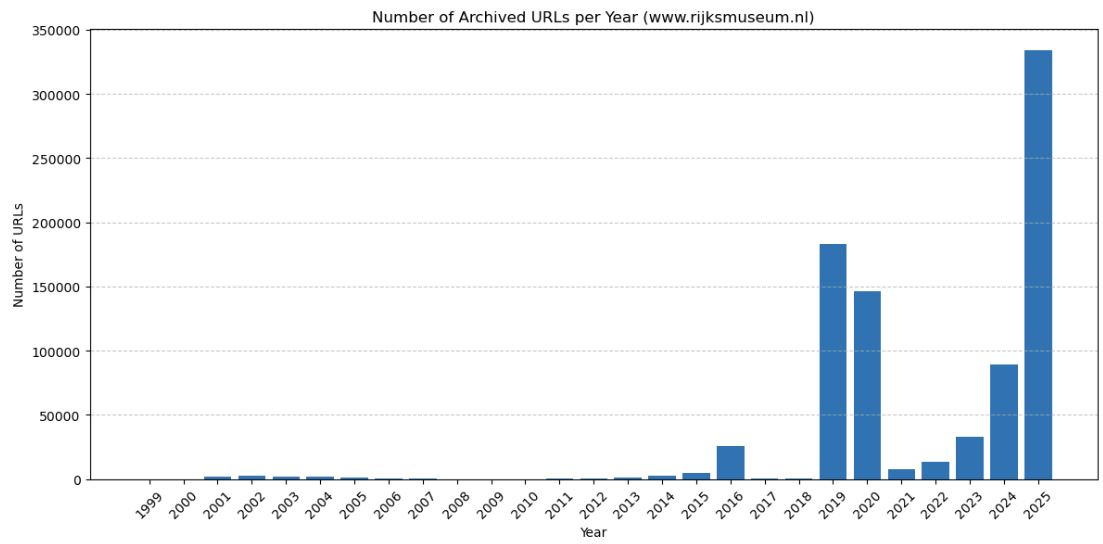

In [11]:
from pathlib import Path
from IPython.display import Image, display

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
IMG_PATH = PROJECT_ROOT / "images" / "yearly_URLs_distribution.jpg"

display(Image(filename=str(IMG_PATH), width=900))

Zooming-in to the period 2011-2018

In [ ]:
# Plotting for 2011-2018
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
file_path = r'data/Rijksmuseum_unique_urls_per_year.csv'
df = pd.read_csv(file_path)

# Ensure 'year' column exists and is an integer
if 'year' not in df.columns:
    df['year'] = pd.to_datetime(df['timestamp'], format='%Y%m%d%H%M%S', errors='coerce').dt.year
else:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')

df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)

# Filter for the desired range: 2011 to 2018
df = df[(df['year'] >= 2011) & (df['year'] <= 2018)]

# Count number of entries per year
year_counts = df['year'].value_counts().sort_index()

# Ensure all years from 2011 to 2018 are included (even if count is 0)
all_years = pd.Series(0, index=range(2011, 2019))
year_counts = all_years.add(year_counts, fill_value=0).astype(int)

# Plot
plt.figure(figsize=(10, 5))
plt.bar(year_counts.index.astype(str), year_counts.values)
plt.title('Archived Rijksmuseum URLs per Year (2011–2018)')
plt.xlabel('Year')
plt.ylabel('Number of URLs')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
The resulting visualisation is in the /images

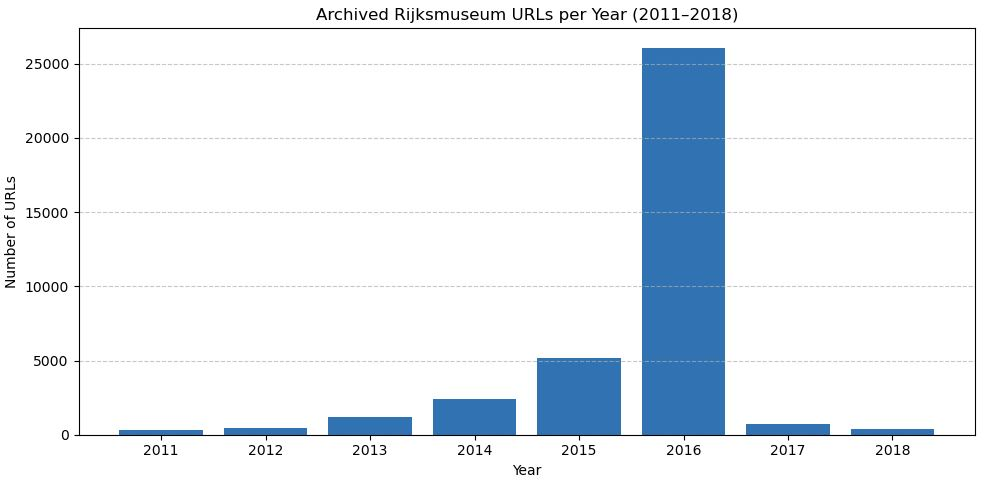

In [12]:
from pathlib import Path
from IPython.display import Image, display

NOTEBOOK_DIR = Path(".").resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
IMG_PATH = PROJECT_ROOT / "images" / "yearly_URLs_distribution_2011-2018.jpg"

display(Image(filename=str(IMG_PATH), width=900))